# 01 Descarga, carga y limpieza del grafo

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Este notebook cubre los pasos 2 a 4 del plan (`docs/hito1`):

- **Paso 2:** descarga de datos y respaldo reproducible
- Paso 3: carga e inventario
- Paso 4: limpieza y proyección

## Paso 2 – Descarga de datos

### 2.1 Configuración, semilla y versiones

In [4]:
import sys, json, hashlib, platform, datetime, time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import shapely
import osmnx as ox
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg

np.random.seed(cfg.SEED)
ox.settings.timeout = 300
ox.settings.requests_timeout = 60   # un intento colgado no bloquea 180 s; se reintenta abajo
ox.settings.use_cache = True
ox.settings.log_console = False

for d in (cfg.DATA_RAW, cfg.DATA_INTERIM, cfg.DATA_PROCESSED):
    d.mkdir(parents=True, exist_ok=True)

versiones = {
    "python": platform.python_version(),
    "osmnx": ox.__version__,
    "networkx": nx.__version__,
    "geopandas": gpd.__version__,
    "shapely": shapely.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
versiones

{'python': '3.13.15',
 'osmnx': '2.1.1',
 'networkx': '3.6.1',
 'geopandas': '1.1.4',
 'shapely': '2.1.2',
 'numpy': '2.1.3',
 'pandas': '2.2.3'}

### 2.2 Límites de los distritos

In [5]:
limites = ox.geocode_to_gdf(cfg.PLACES)
limites["distrito"] = cfg.DISTRICT_LABELS
limites_utm = limites.to_crs(cfg.CRS_METRIC)
limites_utm["area_km2"] = limites_utm.geometry.area / 1e6
limites_utm[["distrito", "area_km2"]].round(2)

,distrito,area_km2
0,Miraflores,9.45
1,San Juan de Miraflores,22.06


### 2.3 Polígono de descarga

Se unen ambos distritos y se agrega un buffer de `BUFFER_M` metros (calculado en UTM, nunca en grados). Así las rutas cercanas al límite no quedan truncadas; en la limpieza se recorta lo que quede fuera de los distritos.

> **Los distritos no son contiguos** (Surco queda entre ambos), por lo que el polígono es un `MultiPolygon` de dos partes y el grafo tendrá al menos dos componentes. Por eso la descarga usa `retain_all=True`: con el valor por defecto (`False`) osmnx conserva solo el componente más grande y descarta el otro distrito completo.

Área de los distritos unidos: 31.51 km²
Área con buffer de 300 m: 45.44 km²


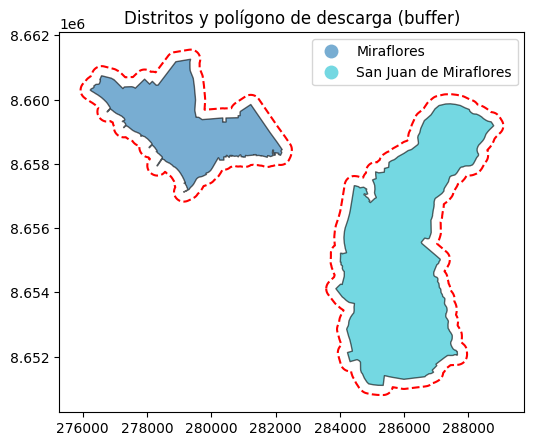

In [6]:
union_utm = limites_utm.geometry.union_all()
poligono_descarga_utm = union_utm.buffer(cfg.BUFFER_M)
poligono_descarga = gpd.GeoSeries([poligono_descarga_utm], crs=cfg.CRS_METRIC).to_crs(4326).iloc[0]

print(f"Área de los distritos unidos: {union_utm.area/1e6:.2f} km²")
print(f"Área con buffer de {cfg.BUFFER_M} m: {poligono_descarga_utm.area/1e6:.2f} km²")

ax = limites_utm.plot(column="distrito", alpha=0.6, edgecolor="k", legend=True, figsize=(6, 6))
gpd.GeoSeries([poligono_descarga_utm], crs=cfg.CRS_METRIC).boundary.plot(ax=ax, color="r", ls="--")
ax.set_title("Distritos y polígono de descarga (buffer)")
plt.show()

### 2.4 Descarga del grafo peatonal

In [7]:
# Overpass a veces tarda en conectar; se reintenta con pausa
for intento in range(1, 13):
    try:
        momento = datetime.datetime.now().astimezone()
        G_raw = ox.graph_from_polygon(poligono_descarga, network_type=cfg.NETWORK_TYPE, simplify=True, retain_all=True)
        break
    except Exception as e:
        print(f"Intento {intento} fallido: {type(e).__name__}")
        if intento == 12:
            raise
        time.sleep(5)
print(f"Descargado: {G_raw.number_of_nodes()} nodos, {G_raw.number_of_edges()} aristas")

Descargado: 17834 nodos, 52768 aristas


### 2.4b Verificación de cobertura

Se comprueba que el grafo contiene nodos de **ambos** distritos antes de guardarlo, y se registra el número de componentes conexos.

In [8]:
nodos_g = ox.graph_to_gdfs(G_raw, edges=False).to_crs(cfg.CRS_METRIC)
etiq = gpd.sjoin(nodos_g[["geometry"]], limites_utm[["distrito", "geometry"]], how="left", predicate="within")
etiq = etiq[~etiq.index.duplicated(keep="first")]["distrito"].fillna("Fuera (buffer)")
nodos_por_distrito = etiq.value_counts().to_dict()
n_componentes = nx.number_weakly_connected_components(G_raw)

print("Nodos por distrito:", nodos_por_distrito)
print("Componentes conexos (débiles):", n_componentes)
faltan = [d for d in cfg.DISTRICT_LABELS if nodos_por_distrito.get(d, 0) == 0]
assert not faltan, f"El grafo no contiene nodos de: {faltan}"

Nodos por distrito: {'San Juan de Miraflores': 9367, 'Fuera (buffer)': 4539, 'Miraflores': 3928}
Componentes conexos (débiles): 112


### 2.5 Respaldo en disco y registro de reproducibilidad

Se guarda el grafo crudo (GraphML), los límites (GeoPackage) y un log con fecha, consulta, versiones, conteos y hash SHA-256.

In [9]:
ruta_grafo = cfg.DATA_RAW / "walk_graph_raw.graphml"
ruta_limites = cfg.DATA_RAW / "limites_distritos.gpkg"
ruta_log = cfg.DATA_RAW / "descarga_log.json"

ox.save_graphml(G_raw, ruta_grafo)
limites[["distrito", "geometry"]].to_file(ruta_limites, driver="GPKG")

def sha256(ruta):
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for bloque in iter(lambda: f.read(1 << 20), b""):
            h.update(bloque)
    return h.hexdigest()

log = {
    "fecha_descarga": momento.isoformat(timespec="seconds"),
    "consulta": {
        "funcion": "ox.graph_from_polygon",
        "lugares": cfg.PLACES,
        "network_type": cfg.NETWORK_TYPE,
        "simplify": True,
        "retain_all": True,
        "buffer_m": cfg.BUFFER_M,
        "crs_buffer": cfg.CRS_METRIC,
    },
    "versiones": versiones,
    "grafo_crudo": {
        "archivo": ruta_grafo.name,
        "nodos": G_raw.number_of_nodes(),
        "aristas": G_raw.number_of_edges(),
        "componentes_debiles": n_componentes,
        "nodos_por_distrito": nodos_por_distrito,
        "sha256": sha256(ruta_grafo),
    },
    "limites": {"archivo": ruta_limites.name, "sha256": sha256(ruta_limites)},
}
ruta_log.write_text(json.dumps(log, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(log, indent=2, ensure_ascii=False))

{
  "fecha_descarga": "2026-10-03T21:50:17+00:00",
  "consulta": {
    "funcion": "ox.graph_from_polygon",
    "lugares": [
      "Miraflores, Lima, Peru",
      "San Juan de Miraflores, Lima, Peru"
    ],
    "network_type": "walk",
    "simplify": true,
    "retain_all": true,
    "buffer_m": 300,
    "crs_buffer": "EPSG:32718"
  },
  "versiones": {
    "python": "3.13.15",
    "osmnx": "2.1.1",
    "networkx": "3.6.1",
    "geopandas": "1.1.4",
    "shapely": "2.1.2",
    "numpy": "2.1.3",
    "pandas": "2.2.3"
  },
  "grafo_crudo": {
    "archivo": "walk_graph_raw.graphml",
    "nodos": 17834,
    "aristas": 52768,
    "componentes_debiles": 112,
    "nodos_por_distrito": {
      "San Juan de Miraflores": 9367,
      "Fuera (buffer)": 4539,
      "Miraflores": 3928
    },
    "sha256": "32ea579d862a9b372905e3881c2b2278908407fdb4bb83b0a657dded43e5f36e"
  },
  "limites": {
    "archivo": "limites_distritos.gpkg",
    "sha256": "ad431d8e650c39decedd5539ba0c3df582824f41ececd2f6eca87fc6

## Carga e inventario del grafo

Se trabaja siempre desde el archivo en disco (`data/raw`), no desde la API, para que los resultados no dependan de la fecha de consulta.

### Carga y estructura general

In [2]:
ruta_grafo = cfg.DATA_RAW / "walk_graph_raw.graphml"
ruta_limites = cfg.DATA_RAW / "limites_distritos.gpkg"

G = ox.load_graphml(ruta_grafo)
limites = gpd.read_file(ruta_limites)

print("Tipo de grafo:", type(G).__name__)
print("CRS del grafo:", G.graph.get("crs"))
print(f"Nodos: {G.number_of_nodes():,} | Aristas: {G.number_of_edges():,}")
print("Atributos de nodos:", sorted({k for _, d in G.nodes(data=True) for k in d}))

nodos, aristas = ox.graph_to_gdfs(G)
print("\nColumnas de aristas:", [c for c in aristas.columns])

Tipo de grafo: MultiDiGraph
CRS del grafo: epsg:4326
Nodos: 17,834 | Aristas: 52,768
Atributos de nodos: ['highway', 'railway', 'street_count', 'x', 'y']



Columnas de aristas: ['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'lanes', 'geometry', 'access', 'service', 'tunnel', 'junction', 'width', 'bridge']


### Estructura de las aristas: bucles, paralelas y simetría

In [3]:
n_bucles = nx.number_of_selfloops(G)
n_paralelas = int((aristas.index.get_level_values("key") > 0).sum())

# Simetría: ¿cada arista u->v tiene su inversa v->u?
pares = set(zip(aristas.index.get_level_values("u"), aristas.index.get_level_values("v")))
con_inversa = sum((v, u) in pares for u, v in pares)
print(f"Bucles (self-loops): {n_bucles}")
print(f"Aristas paralelas (key > 0): {n_paralelas}")
print(f"Pares dirigidos únicos: {len(pares):,} | con arista inversa: {con_inversa:,} ({con_inversa/len(pares):.1%})")
print("Valores de 'oneway':", aristas["oneway"].astype(str).value_counts().to_dict())

Bucles (self-loops): 70
Aristas paralelas (key > 0): 425
Pares dirigidos únicos: 52,343 | con arista inversa: 52,343 (100.0%)
Valores de 'oneway': {'False': 52768}


### Tipos de vía (`highway`)

Las aristas simplificadas pueden traer listas de valores; se cuentan por separado.

In [4]:
hw = aristas["highway"].apply(lambda v: v if isinstance(v, list) else [v])
print(f"Aristas con más de un tipo de vía (lista): {(hw.str.len() > 1).sum():,}\n")
conteo_hw = hw.explode().value_counts()
pd.DataFrame({"aristas": conteo_hw, "%": (conteo_hw / conteo_hw.sum() * 100).round(1)})

Aristas con más de un tipo de vía (lista): 640



,aristas,%
highway,,
residential,22056,41.3
footway,15938,29.8
secondary,3886,7.3
tertiary,3040,5.7
service,2460,4.6
steps,2362,4.4
primary,966,1.8
path,902,1.7
pedestrian,480,0.9


### Nodos por distrito

El grafo se descargó con un buffer de 300 m, por lo que una parte de los nodos cae fuera de ambos distritos. Se etiquetan por join espacial para saber cuántos hay en cada uno (la etiqueta definitiva se asigna en la limpieza).

In [5]:
nodos_utm = nodos.to_crs(cfg.CRS_METRIC)
limites_utm = limites.to_crs(cfg.CRS_METRIC)
etiqueta = gpd.sjoin(nodos_utm[["geometry"]], limites_utm[["distrito", "geometry"]], how="left", predicate="within")
etiqueta = etiqueta[~etiqueta.index.duplicated(keep="first")]["distrito"].fillna("Fuera (buffer)")
tabla_distrito = etiqueta.value_counts().rename("nodos").to_frame()
tabla_distrito["%"] = (tabla_distrito["nodos"] / tabla_distrito["nodos"].sum() * 100).round(1)
tabla_distrito

,nodos,%
distrito,,
San Juan de Miraflores,9367,52.5
Fuera (buffer),4539,25.5
Miraflores,3928,22.0


### Componentes conexos

Los dos distritos no son contiguos, así que se esperan dos componentes grandes y varios fragmentos pequeños. Para cada componente se indica en qué zona cae la mayoría de sus nodos.

In [6]:
comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
filas = []
for k, c in enumerate(comps, start=1):
    zona = etiqueta.reindex(list(c)).value_counts()
    filas.append({"componente": k, "nodos": len(c), "zona_mayoritaria": zona.index[0], "% en esa zona": round(zona.iloc[0] / len(c) * 100, 1)})
tabla_comp = pd.DataFrame(filas)
print(f"Componentes: {len(comps)} | nodos en los dos mayores: {tabla_comp['nodos'].head(2).sum():,} ({tabla_comp['nodos'].head(2).sum() / G.number_of_nodes():.1%})")
print(f"Fragmentos pequeños (resto): {len(comps) - 2} componentes, {tabla_comp['nodos'].iloc[2:].sum()} nodos, el mayor de {tabla_comp['nodos'].iloc[2]} nodos")
tabla_comp.head(5)

Componentes: 112 | nodos en los dos mayores: 17,265 (96.8%)
Fragmentos pequeños (resto): 110 componentes, 569 nodos, el mayor de 39 nodos


,componente,nodos,zona_mayoritaria,% en esa zona
0,1,11465,San Juan de Miraflores,79.6
1,2,5800,Miraflores,66.2
2,3,39,Fuera (buffer),100.0
3,4,34,Fuera (buffer),100.0
4,5,25,San Juan de Miraflores,100.0


### Datos faltantes en aristas

El enunciado exige reportar el porcentaje de aristas sin `maxspeed`, `lanes` y `name`. Se calcula para todas las columnas de atributos (un valor tipo lista cuenta como presente).

In [7]:
atributos = [c for c in aristas.columns if c not in ("geometry",)]
faltantes = aristas[atributos].isna().mean().mul(100).round(1).rename("% faltante")
tabla_faltantes = faltantes.to_frame().assign(aristas_con_dato=lambda d: ((100 - d["% faltante"]) / 100 * len(aristas)).round().astype(int))
tabla_faltantes.sort_values("% faltante", ascending=False)

,% faltante,aristas_con_dato
junction,99.9,53
tunnel,99.8,106
bridge,99.6,211
access,99.5,264
width,99.5,264
service,98.9,580
maxspeed,76.9,12189
lanes,70.0,15830
name,52.8,24906
highway,0.0,52768


In [8]:
# Faltantes de los tres atributos pedidos, por distrito de la arista (según su nodo de origen)
u = aristas.index.get_level_values("u")
aristas_dist = pd.Series(etiqueta.reindex(u).values, index=aristas.index, name="distrito")
clave = ["name", "maxspeed", "lanes"]
por_distrito = (aristas[clave].isna().groupby(aristas_dist.values).mean() * 100).round(1)
por_distrito.columns = [f"% sin {c}" for c in clave]
por_distrito.assign(aristas=aristas_dist.value_counts())

,% sin name,% sin maxspeed,% sin lanes,aristas
Fuera (buffer),48.8,75.2,68.4,12596
Miraflores,44.2,51.2,51.8,11685
San Juan de Miraflores,58.2,88.1,78.2,28487


### Distribución de longitudes de arista (m)

Longitudes en el CRS original se calculan por el atributo `length` que provee osmnx (en metros).

In [9]:
aristas["length"].describe().round(2).to_frame("length (m)")

,length (m)
count,52768.00
mean,47.03
std,50.88
min,0.11
25%,15.01
50%,37.26
75%,59.84
max,2432.36


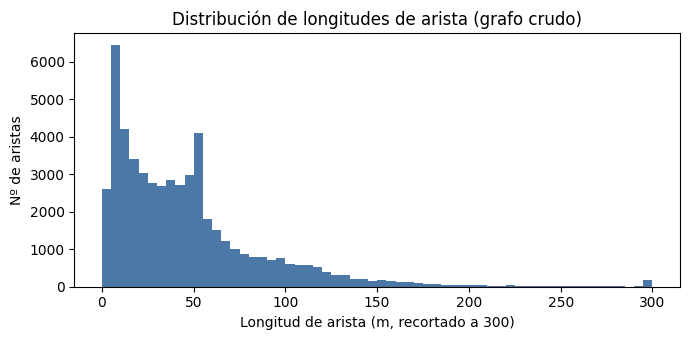

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(aristas["length"].clip(upper=300), bins=60, color="#4c78a8")
ax.set_xlabel("Longitud de arista (m, recortado a 300)")
ax.set_ylabel("Nº de aristas")
ax.set_title("Distribución de longitudes de arista (grafo crudo)")
plt.tight_layout()
plt.show()

### Hallazgos del inventario

- **Tamaño:** 17 834 nodos y 52 768 aristas; cumple los mínimos (3 000 / 6 000) y el tope recomendado (60 000).
- **Simetría:** `oneway` es falso en el 100 % de las aristas y todas tienen su inversa, así que el grafo peatonal es en la práctica no dirigido.
- **Componentes:** 112; los dos mayores (SJM y Miraflores, cada uno con su buffer) reúnen el 96.8 % de los nodos. Los otros 110 son fragmentos de 39 nodos o menos (569 nodos en total) y se tratarán en la limpieza.
- **Buffer:** el 25.5 % de los nodos queda fuera de ambos distritos y debe recortarse o etiquetarse antes de calcular métricas por distrito.
- **Tipos de vía:** `residential` (41.3 %) y `footway` (29.8 %) dominan; hay 4.4 % de escaleras (`steps`), relevante para la accesibilidad en SJM.
- **Datos faltantes:** `maxspeed` 76.9 %, `lanes` 70.0 % y `name` 52.8 %; peor en SJM (88.1 %, 78.2 %, 58.2 %) que en Miraflores (51.2 %, 51.8 %, 44.2 %). No se imputan, porque el análisis peatonal usa una velocidad de caminata constante.
- **Anomalías por revisar:** 70 bucles, 425 aristas paralelas, longitudes desde 0.11 m hasta 2 432 m (posibles outliers), y 640 aristas con `highway` en forma de lista.

## Limpieza y proyección

Decisiones de diseño (justificadas en el informe):

1. **Proyección** a EPSG:32718 antes de cualquier cálculo de distancias o áreas.
2. **Buffer:** los nodos que caen fuera de ambos distritos **no se eliminan**: se etiquetan como `Fuera (buffer)` y se usan solo para el ruteo, de modo que las rutas cercanas al límite no queden truncadas (efecto de borde). Las métricas por distrito usarán solo los nodos etiquetados con su distrito.
3. **Componentes:** se conserva el componente conexo principal de cada distrito (el que contiene más nodos de ese distrito) y se descartan los fragmentos aislados.
4. **Bucles y aristas paralelas:** se eliminan los bucles y, entre aristas paralelas, se conserva la más corta (no aportan a caminos mínimos ni a la accesibilidad).
5. **Atributos:** los valores tipo lista se normalizan; `maxspeed`, `lanes` y `name` faltantes **no se imputan** (el análisis peatonal usa velocidad constante).
6. Las longitudes extremas se revisan pero no se eliminan, porque quitar aristas podría desconectar la red.

### Carga del grafo crudo y registro de cambios

In [2]:
G = ox.load_graphml(cfg.DATA_RAW / "walk_graph_raw.graphml")
limites_utm = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)

registro = []
def anotar(paso, H):
    registro.append({
        "paso": paso,
        "nodos": H.number_of_nodes(),
        "aristas": H.number_of_edges(),
        "componentes": nx.number_weakly_connected_components(H),
    })

anotar("Grafo crudo", G)
pd.DataFrame(registro)

,paso,nodos,aristas,componentes
0,Grafo crudo,17834,52768,112


### Proyección a EPSG:32718 y validación de longitudes

In [3]:
Gp = ox.project_graph(G, to_crs=cfg.CRS_METRIC)
print("CRS del grafo proyectado:", Gp.graph["crs"])

_, e_p = ox.graph_to_gdfs(Gp)
razon = e_p.geometry.length / e_p["length"]
print("Razón (longitud de la geometría proyectada / atributo 'length'):")
print(razon.describe().round(5).to_string())
print(f"Aristas con diferencia > 1 %: {(abs(razon - 1) > 0.01).sum()}")

CRS del grafo proyectado: EPSG:32718


Razón (longitud de la geometría proyectada / atributo 'length'):
count    52768.00000
mean         0.99818
std          0.00226
min          0.99501
25%          0.99586
50%          0.99816
75%          1.00050
max          1.00148
Aristas con diferencia > 1 %: 0


### Etiqueta de distrito por nodo

Join espacial en UTM entre los nodos y los polígonos de los distritos.

In [4]:
nodos_p = ox.graph_to_gdfs(Gp, edges=False)
j = gpd.sjoin(nodos_p[["geometry"]], limites_utm[["distrito", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated(keep="first")]
etiqueta = j["distrito"].fillna("Fuera (buffer)")
nx.set_node_attributes(Gp, etiqueta.to_dict(), "distrito")
etiqueta.value_counts().to_frame("nodos")

,nodos
distrito,
San Juan de Miraflores,9367
Fuera (buffer),4539
Miraflores,3928


### Componentes: se conserva el principal de cada distrito

In [5]:
comps = list(nx.weakly_connected_components(Gp))
dist_de = etiqueta.to_dict()
conservar, detalle = set(), []
for d in cfg.DISTRICT_LABELS:
    cuenta = [sum(dist_de[n] == d for n in c) for c in comps]
    k = int(np.argmax(cuenta))
    conservar |= comps[k]
    detalle.append({"distrito": d, "nodos_del_distrito_en_el_componente": cuenta[k],
                    "nodos_totales_del_componente": len(comps[k]),
                    "% de los nodos del distrito": round(cuenta[k] / sum(v == d for v in dist_de.values()) * 100, 1)})
descartados = [n for n in Gp.nodes if n not in conservar]
print(f"Nodos descartados (fragmentos aislados): {len(descartados)} en {len(comps) - len(cfg.DISTRICT_LABELS)} componentes")

Gc = Gp.subgraph(conservar).copy()
anotar("Componente principal por distrito", Gc)
pd.DataFrame(detalle)

Nodos descartados (fragmentos aislados): 569 en 110 componentes


,distrito,nodos_del_distrito_en_el_componente,nodos_totales_del_componente,% de los nodos del distrito
0,Miraflores,3841,5800,97.8
1,San Juan de Miraflores,9127,11465,97.4


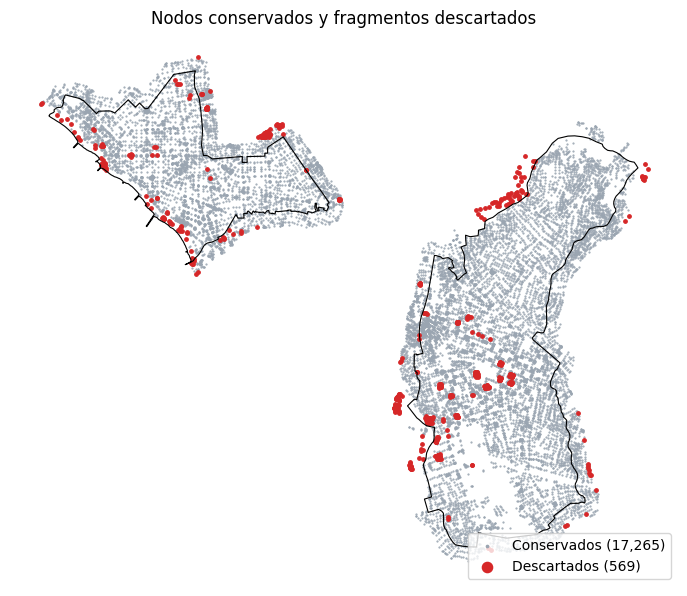

In [6]:
nodos_c = ox.graph_to_gdfs(Gc, edges=False)
desc = nodos_p.loc[descartados]
fig, ax = plt.subplots(figsize=(7, 6))
limites_utm.boundary.plot(ax=ax, color="k", lw=0.8)
nodos_c.plot(ax=ax, markersize=0.3, color="#9aa5b1", label=f"Conservados ({len(nodos_c):,})")
desc.plot(ax=ax, markersize=6, color="#d62728", label=f"Descartados ({len(desc):,})")
ax.legend(loc="lower right", markerscale=3)
ax.set_title("Nodos conservados y fragmentos descartados")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Bucles y aristas paralelas

In [7]:
bucles = list(nx.selfloop_edges(Gc, keys=True))
Gc.remove_edges_from(bucles)

por_par = {}
for u, v, k, d in Gc.edges(keys=True, data=True):
    por_par.setdefault((u, v), []).append((d["length"], k))
paralelas = [(u, v, k) for (u, v), lst in por_par.items() if len(lst) > 1 for _, k in sorted(lst)[1:]]
Gc.remove_edges_from(paralelas)

# street_count cambia al quitar aristas: se recalcula
nx.set_node_attributes(Gc, ox.stats.count_streets_per_node(Gc), "street_count")

print(f"Bucles eliminados: {len(bucles)} | aristas paralelas eliminadas: {len(paralelas)}")
anotar("Sin bucles ni paralelas", Gc)

Bucles eliminados: 70 | aristas paralelas eliminadas: 352


### Normalización de atributos

- `highway_main`: un único tipo de vía por arista. Cuando hay varios, se toma el de mayor jerarquía según `PRIORIDAD`; el valor original se conserva en `highway`.
- `tiene_escalera`: indica si algún tramo de la arista es `steps`.
- Los atributos de texto con lista (`name`, `maxspeed`, `lanes`, etc.) se unen con `;`. `osmid` y `reversed` se dejan como están: osmnx los lee como entero/booleano o como lista, y un texto unido con `;` impide recargar el grafo.

In [8]:
PRIORIDAD = ["trunk", "trunk_link", "primary", "primary_link", "secondary", "secondary_link",
             "tertiary", "tertiary_link", "unclassified", "residential", "living_street", "service",
             "pedestrian", "footway", "corridor", "path", "track", "bridleway", "busway", "steps", "ladder"]

def como_lista(v):
    return v if isinstance(v, list) else [v]

def principal(v):
    return min(como_lista(v), key=lambda x: PRIORIDAD.index(x) if x in PRIORIDAD else len(PRIORIDAD))

n_listas = 0
for u, v, k, d in Gc.edges(keys=True, data=True):
    hw = como_lista(d["highway"])
    d["highway_main"] = principal(hw)
    d["tiene_escalera"] = "steps" in hw
    d["highway"] = ";".join(hw)
    for a in ("name", "maxspeed", "lanes", "width", "service", "access", "junction", "bridge", "tunnel"):
        if isinstance(d.get(a), list):
            d[a] = ";".join(map(str, d[a]))
            n_listas += 1

print(f"Atributos tipo lista unidos con ';': {n_listas}")
_, e_c = ox.graph_to_gdfs(Gc)
e_c["highway_main"].value_counts().to_frame("aristas")

Atributos tipo lista unidos con ';': 268


,aristas
highway_main,
residential,21848
footway,14834
secondary,3864
tertiary,3028
service,2248
steps,1986
primary,952
path,806
pedestrian,474


### Longitudes extremas

Se revisan las aristas más cortas y más largas. No se eliminan: quitar aristas podría desconectar la red.

In [9]:
print(f"Aristas < 1 m: {(e_c['length'] < 1).sum()} | aristas > 500 m: {(e_c['length'] > 500).sum()}")
e_c.nlargest(6, "length")[["highway_main", "name", "length", "tiene_escalera"]].round(1)

Aristas < 1 m: 24 | aristas > 500 m: 24


,,,highway_main,name,length,tiene_escalera
u,v,key,,,,
5999469305,5999469337,0,residential,NaN,737.7,False
5999469337,5999469305,0,residential,NaN,737.7,False
10722291730,6129187429,0,footway,NaN,726.9,False
6129187429,10722291730,0,footway,NaN,726.9,False
1674152953,4334059587,0,secondary,Avenida Mateo Pumacahua,657.0,False
4334059587,1674152953,0,secondary,Avenida Mateo Pumacahua,657.0,False


### Resumen del proceso de limpieza

In [10]:
tabla_limpieza = pd.DataFrame(registro)
tabla_limpieza["Δ nodos"] = tabla_limpieza["nodos"].diff().fillna(0).astype(int)
tabla_limpieza["Δ aristas"] = tabla_limpieza["aristas"].diff().fillna(0).astype(int)
tabla_limpieza

,paso,nodos,aristas,componentes,Δ nodos,Δ aristas
0,Grafo crudo,17834,52768,112,0,0
1,Componente principal por distrito,17265,51638,2,-569,-1130
2,Sin bucles ni paralelas,17265,51216,2,0,-422


### Verificación final y exportación

Criterios de aceptación: ≥ 3 000 nodos y ≥ 6 000 aristas, todo en EPSG:32718, un componente por distrito y ambos distritos presentes.

In [11]:
etiq_final = pd.Series(nx.get_node_attributes(Gc, "distrito"))
comp_final = nx.number_weakly_connected_components(Gc)
assert Gc.number_of_nodes() >= 3000 and Gc.number_of_edges() >= 6000
assert str(Gc.graph["crs"]).upper().endswith("32718")
assert all((etiq_final == d).any() for d in cfg.DISTRICT_LABELS)
assert comp_final == len(cfg.DISTRICT_LABELS), comp_final
print(f"OK: {Gc.number_of_nodes():,} nodos, {Gc.number_of_edges():,} aristas, {comp_final} componentes, CRS {Gc.graph['crs']}")
print(etiq_final.value_counts().to_string())

OK: 17,265 nodos, 51,216 aristas, 2 componentes, CRS EPSG:32718
San Juan de Miraflores    9127
Fuera (buffer)            4297
Miraflores                3841


In [12]:
ruta_clean = cfg.DATA_INTERIM / "walk_graph_clean.graphml"
ruta_gpkg = cfg.DATA_PROCESSED / "walk_graph_clean.gpkg"
ruta_reg = cfg.DATA_PROCESSED / "limpieza_registro.csv"

ox.save_graphml(Gc, ruta_clean)

# El archivo debe poder recargarse igual que se guardó
G_check = ox.load_graphml(ruta_clean)
assert (G_check.number_of_nodes(), G_check.number_of_edges()) == (Gc.number_of_nodes(), Gc.number_of_edges())

n_gdf, e_gdf = ox.graph_to_gdfs(Gc)
e_gdf = e_gdf.reset_index()
n_gdf = n_gdf.reset_index()
for df in (n_gdf, e_gdf):
    for col in df.columns:
        if df[col].dtype == object and col != "geometry":
            df[col] = df[col].apply(lambda x: ";".join(map(str, x)) if isinstance(x, list) else x)
n_gdf.to_file(ruta_gpkg, layer="nodos", driver="GPKG")
e_gdf.to_file(ruta_gpkg, layer="aristas", driver="GPKG")
tabla_limpieza.to_csv(ruta_reg, index=False)
print([f"{p.name}: {p.stat().st_size/1e6:.1f} MB" for p in (ruta_clean, ruta_gpkg, ruta_reg)])

['walk_graph_clean.graphml: 26.8 MB', 'walk_graph_clean.gpkg: 15.3 MB', 'limpieza_registro.csv: 0.0 MB']


### Resultados de la limpieza

| Etapa | Nodos | Aristas | Componentes |
|---|---:|---:|---:|
| Grafo crudo | 17 834 | 52 768 | 112 |
| Componente principal por distrito | 17 265 | 51 638 | 2 |
| Sin bucles ni paralelas | 17 265 | 51 216 | 2 |

- **Proyección:** el grafo queda en EPSG:32718. La longitud de la geometría proyectada coincide con el atributo `length` (razón 0.995–1.001, ninguna arista con diferencia > 1 %), lo que valida la proyección.
- **Fragmentos:** se descartan 569 nodos en 110 componentes. El componente conservado de cada distrito contiene el 97.8 % (Miraflores) y el 97.4 % (SJM) de los nodos etiquetados en ese distrito.
- **Bucles y paralelas:** 70 bucles y 352 aristas paralelas eliminadas (de las 425 paralelas iniciales, el resto estaba en los fragmentos descartados).
- **Longitudes extremas:** tras descartar los fragmentos, la arista más larga mide 737.7 m (calle residencial sin nombre) y hay 24 aristas < 1 m y 24 > 500 m. Se conservan; las más largas son tramos continuos sin intersecciones (p. ej. la Av. Mateo Pumacahua, 657 m).
- **Buffer:** quedan 4 297 nodos `Fuera (buffer)` (24.9 %), usados solo para el ruteo.
- **Escaleras:** 1 986 aristas con `highway_main = steps`.
- **Grafo final:** 17 265 nodos, 51 216 aristas, 2 componentes (uno por distrito): Miraflores 3 841 nodos, SJM 9 127 y buffer 4 297.

**Pendiente:** el enunciado pide explicar el efecto de `simplify=True` sobre el conteo de nodos. Requiere una descarga sin simplificar, que no es posible desde este entorno; se hará en Colab.

## Efecto de la simplificación (`simplify=True`)

El enunciado pide explicar el efecto de `simplify=True` sobre el conteo de nodos. En OpenStreetMap cada calle se dibuja con muchos puntos intermedios (nodos de geometría) que no son intersecciones. La simplificación los elimina y deja solo intersecciones y finales de vía, fusionando los tramos en una arista que conserva la geometría.

El notebook `01b_efecto_simplify_colab` descarga **una vez** el grafo **sin simplificar** de la misma zona y lo simplifica con `ox.simplify_graph`, de modo que ambas versiones salen de los mismos datos (resultado en `data/raw/simplify_comparacion.json`).

### Comparación global

In [2]:
import json
comp = json.loads((cfg.DATA_RAW / "simplify_comparacion.json").read_text(encoding="utf-8"))
print("Descarga de la comparación:", comp["fecha_descarga"], "| osmnx", comp["versiones"]["osmnx"])

tabla_simp = pd.DataFrame({"sin simplificar": comp["sin_simplificar"], "simplificado": comp["simplificado"]})
tabla_simp["cambio"] = tabla_simp["simplificado"] - tabla_simp["sin simplificar"]
tabla_simp["cambio %"] = (tabla_simp["cambio"] / tabla_simp["sin simplificar"] * 100).round(1)
tabla_simp.round(2)

Descarga de la comparación: 2026-10-03T23:21:52+00:00 | osmnx 2.1.1


,sin simplificar,simplificado,cambio,cambio %
nodos,42545.00,17787.00,-24758.00,-58.2
aristas,102158.00,52642.00,-49516.00,-48.5
longitud media de arista (m),24.55,47.50,22.95,93.5
"longitud total (km, aristas dirigidas / 2)",1254.14,1250.25,-3.90,-0.3
nodos de geometría (street_count = 2),24711.00,202.00,-24509.00,-99.2
nodos de intersección (street_count >= 3),15729.00,15480.00,-249.00,-1.6
calles sin salida (street_count = 1),2105.00,2105.00,0.00,0.0
componentes (débiles),138.00,123.00,-15.00,-10.9


### Por distrito y normalizado por área

Un nodo pertenece al distrito cuyo polígono lo contiene. Como el enunciado exige normalizar por área, se compara también la densidad de nodos por km² antes y después de simplificar.

In [3]:
limites_a = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)
area = limites_a.set_index("distrito").geometry.area / 1e6
nd = pd.DataFrame(comp["nodos_por_distrito"]).rename(columns={"sin_simplificar": "nodos sin simplificar", "simplificado": "nodos simplificados"})
nd["% eliminado"] = ((1 - nd["nodos simplificados"] / nd["nodos sin simplificar"]) * 100).round(1)
print("Nodos por zona:")
print(nd.loc[cfg.DISTRICT_LABELS + ["Fuera (buffer)"]].to_string())

dens = pd.DataFrame({
    "nodos / km² sin simplificar": nd.loc[cfg.DISTRICT_LABELS, "nodos sin simplificar"] / area.loc[cfg.DISTRICT_LABELS],
    "nodos / km² simplificado": nd.loc[cfg.DISTRICT_LABELS, "nodos simplificados"] / area.loc[cfg.DISTRICT_LABELS],
}).round(0)
dens.loc["razón Miraflores / SJM"] = (dens.loc["Miraflores"] / dens.loc["San Juan de Miraflores"]).round(2)
print("\nDensidad de nodos:")
dens

Nodos por zona:
                        nodos sin simplificar  nodos simplificados  % eliminado
Miraflores                              10859                 3928         63.8
San Juan de Miraflores                  19617                 9367         52.3
Fuera (buffer)                          12069                 4492         62.8

Densidad de nodos:


,nodos / km² sin simplificar,nodos / km² simplificado
Miraflores,1150.00,416.00
San Juan de Miraflores,889.00,425.00
razón Miraflores / SJM,1.29,0.98


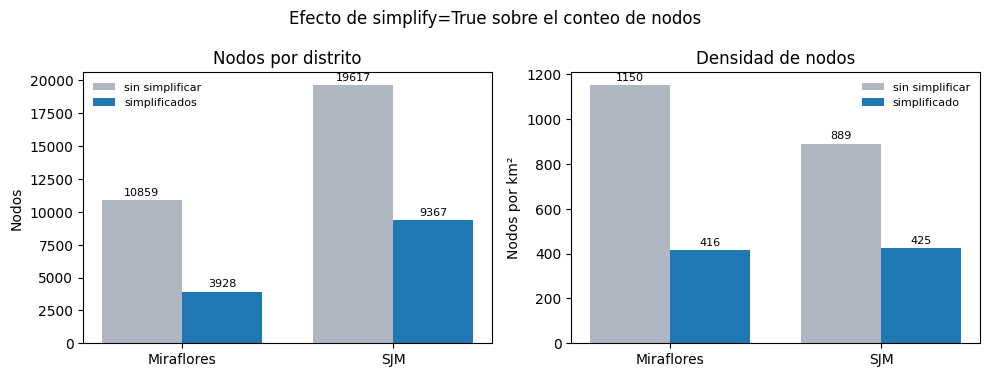

In [4]:
from src import mapas

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
x = np.arange(len(cfg.DISTRICT_LABELS))
for ax, (titulo, cols, ylab) in zip(axs, [
    ("Nodos por distrito", ["nodos sin simplificar", "nodos simplificados"], "Nodos"),
    ("Densidad de nodos", ["nodos / km² sin simplificar", "nodos / km² simplificado"], "Nodos por km²"),
]):
    base = nd.loc[cfg.DISTRICT_LABELS] if "Nodos por" in titulo else dens.loc[cfg.DISTRICT_LABELS]
    for k, (c, color) in enumerate(zip(cols, ["#b0b7c3", "#1f77b4"])):
        b = ax.bar(x + (k - 0.5) * 0.38, base[c].to_numpy(), 0.38, color=color, label=c.replace("nodos / km² ", "").replace("nodos ", ""))
        ax.bar_label(b, fmt="%.0f", fontsize=8, padding=2)
    ax.set_xticks(x, ["Miraflores", "SJM"])
    ax.set(title=titulo, ylabel=ylab)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Efecto de simplify=True sobre el conteo de nodos")
fig.tight_layout()
mapas.guardar(fig, cfg.FIG_PLOTS / "hito1_10_efecto_simplify.png")
plt.show()

### Efecto de la simplificación: conclusiones

1. **Reduce el conteo de nodos a menos de la mitad:** de 42 545 a 17 787 nodos (−58.2 %) y de 102 158 a 52 642 aristas (−48.5 %). Casi todo lo eliminado son **nodos de geometría** (los de `street_count = 2`): 24 711, el 58 % de los nodos del grafo sin simplificar; tras simplificar quedan 202. Que no lleguen a cero es consistente con que osmnx no fusiona tramos cuyos atributos difieren, aunque no se verificó caso por caso.
2. **Conserva la estructura de la red:** las calles sin salida no cambian (2 105) y las intersecciones casi no (15 729 → 15 480, −1.6 %). La longitud total de vía varía −0.3 % (−3.9 km); la longitud media de arista pasa de 24.6 m a 47.5 m, porque los tramos se fusionan. La pequeña diferencia en intersecciones, longitud y componentes (138 → 123) es consistente con que osmnx elimina anillos y componentes aislados al simplificar, pero no se comprobó.
3. **El conteo sin simplificar no es comparable entre distritos:** la reducción es mayor en Miraflores (−63.8 %) que en San Juan de Miraflores (−52.3 %). Sin simplificar, Miraflores parece un 29 % más denso (1 150 frente a 889 nodos/km²); simplificado, las densidades son casi iguales (416 frente a 425, razón 0.98). La diferencia sin simplificar refleja cuántos puntos usó el mapeador para dibujar las curvas, no la estructura de la red. Por eso las densidades se reportan sobre el grafo simplificado y, en particular, como densidad de **intersecciones** (grado ≥ 3).
4. **Decisión:** se usa `simplify=True`, como pide el enunciado, porque conserva intersecciones, calles sin salida y longitud total, y hace comparables las densidades entre distritos.

**Notas:**
- La comparación se descargó a las 23:21 UTC y el grafo de análisis a las 21:50 UTC. El simplificado de la comparación tiene 17 787 nodos frente a 17 834 del grafo de análisis; la diferencia de 47 nodos está en el buffer (4 492 frente a 4 539) y se debe a ediciones de OSM entre ambas descargas: los dos distritos coinciden exactamente (Miraflores 3 928, SJM 9 367). El análisis sigue usando el grafo de las 21:50 UTC.
- Las densidades de esta sección se calculan sobre el grafo antes de la limpieza, por lo que difieren un poco de las del análisis exploratorio (407 y 414 nodos/km² con el grafo limpio, sin fragmentos).